# Block 04 - deterministic nowcasts

The session's case: extrapolation and S-PROG from the last radar fields before
2022-08-18 08:45 (the session went to 12 lead times; here six 15-min steps, 90 min), plus
ANVIL and LINDA. Then
the session's verification - POD, FAR, ETS and ME by lead time - and FSS and SAL; and the
same nowcast made from every product, as the session's last exercise did.

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from core import viz_style as vs
from os_nowcasting import data, grid, nowcast, plots, products, verify
vs.use_style()

In [2]:
NET, STEP = "openrainer", 15
radar = data.radar(NET, "2022-08-18 05:45", "2022-08-18 11:00")
rate, meta = grid.to_pysteps(radar, STEP)
times = pd.DatetimeIndex(radar.time.values)
ISSUE = times.get_loc(pd.Timestamp("2022-08-18 08:45"))
print(rate.shape, "pixels of", meta["xpixelsize"] / 1000, "km; issue time", times[ISSUE])

(22, 97, 155) pixels of 2.0000659081611216 km; issue time 2022-08-18 08:45:00


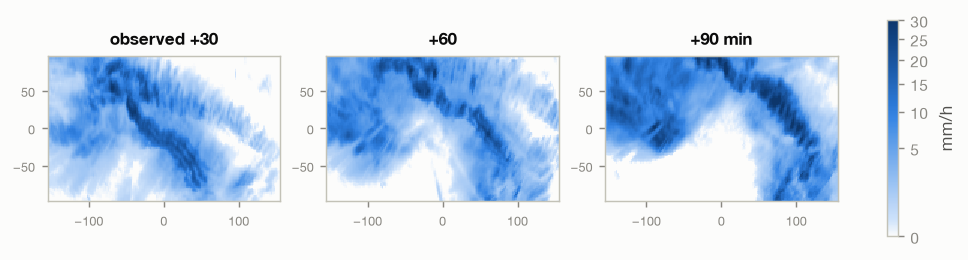

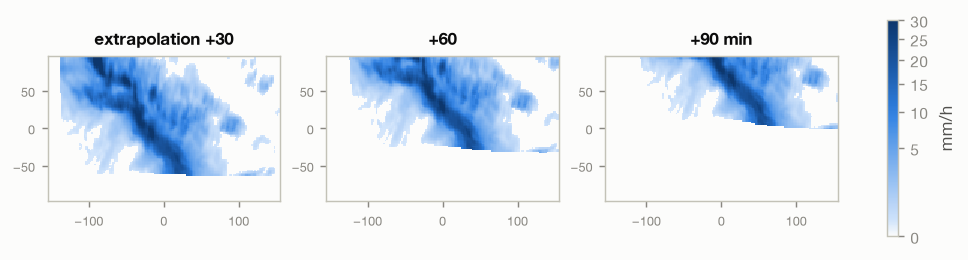

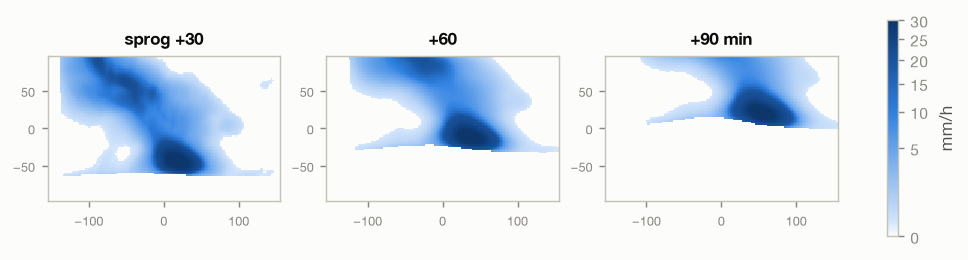

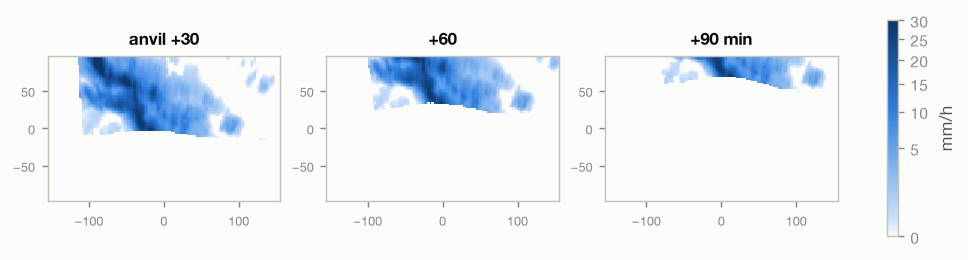

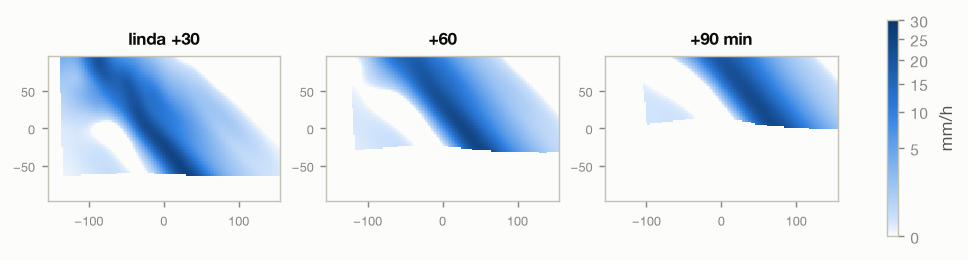

In [3]:
N = 6
past, obs = rate[:ISSUE + 1], rate[ISSUE + 1:ISSUE + 1 + N]
v = nowcast.motion(past, meta, "LK")
F = {m: nowcast.deterministic(m, past, meta, v, N) for m in ["persistence", "extrapolation", "sprog", "anvil", "linda"]}
fig, axes = plots.row([obs[1], obs[3], obs[5]], ["observed +30", "+60", "+90 min"], meta, vmax=30)
for m in ["extrapolation", "sprog", "anvil", "linda"]:
    fig, axes = plots.row([F[m][1], F[m][3], F[m][5]], [f"{m} +30", "+60", "+90 min"], meta, vmax=30)

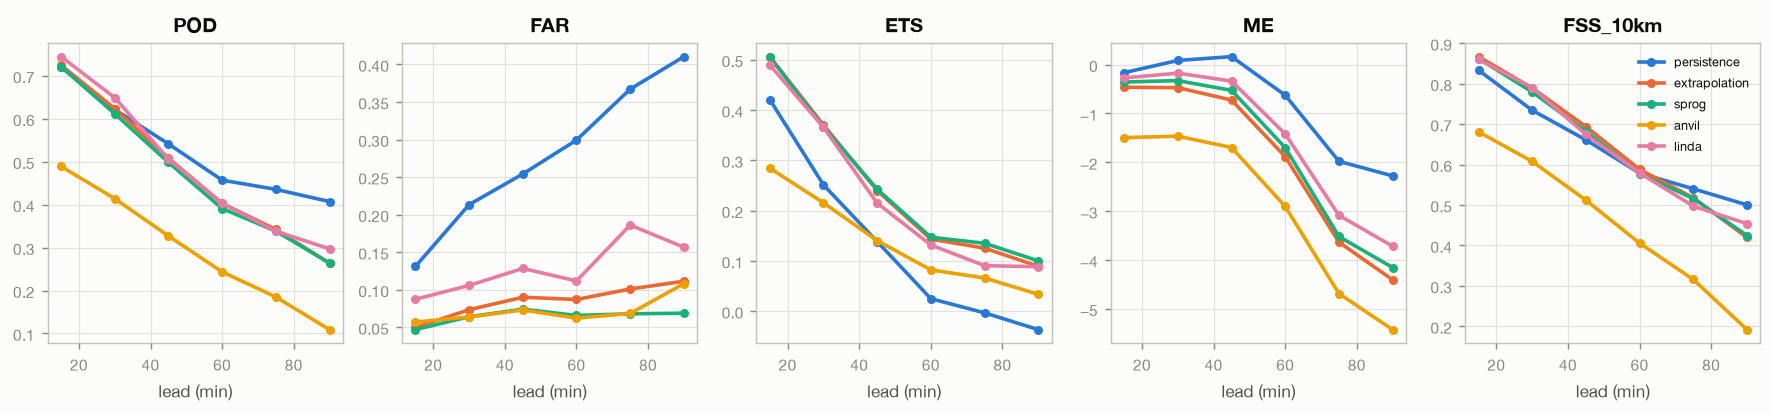

In [4]:
from pysteps.verification import detcatscores, detcontscores, spatialscores
rows = []
for m, f in F.items():
    for k in range(N):
        c = detcatscores.det_cat_fct(f[k], obs[k], thr=1.0, scores=["POD", "FAR", "ETS"])
        e = detcontscores.det_cont_fct(f[k], obs[k], scores=["ME"])
        rows.append({"method": m, "lead_min": 15 * (k + 1), **c, **e,
                     "FSS_10km": spatialscores.fss(f[k], obs[k], 1.0, 5)})
scores = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 5, figsize=(17, 3))
for ax, s in zip(axes, ["POD", "FAR", "ETS", "ME", "FSS_10km"]):
    for k, (m, g) in enumerate(scores.groupby("method", sort=False)):
        ax.plot(g.lead_min, g[s], marker="o", markersize=4, label=m, color=["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"][k])
    ax.set_title(s); ax.set_xlabel("lead (min)")
axes[-1].legend(fontsize=7);

In [5]:
pd.DataFrame({m: verify.sal_score(F[m][3], obs[3]) for m in F}, index=["S", "A", "L"]).round(2)

,persistence,extrapolation,sprog,anvil,linda
S,-0.43,-0.66,-0.71,-1.06,-0.12
A,-0.15,-0.55,-0.48,-0.99,-0.39
L,0.11,0.09,0.12,0.14,0.13


## Every product nowcast with S-PROG

The session's closing exercise. Each product is nowcast from its own past; the table scores
the 60-min nowcast against the product's own field and against the radar.

CSI_1       FSS_10km      
reference   own radar      own radar
product                             
cml_idw10  0.15  0.05     0.27  0.10
cml_idw20  0.28  0.18     0.49  0.34
cml_idw40  0.33  0.37     0.52  0.58
merged     0.29  0.27     0.48  0.45
radar      0.38  0.38     0.58  0.58

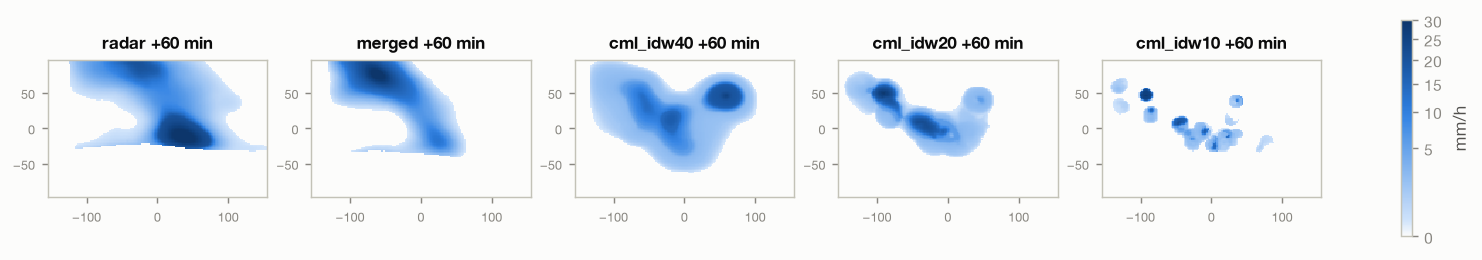

In [6]:
prods = products.build(NET, radar.time.values[0], radar.time.values[-1], radar)
rows, panels = [], []
for k in ["radar", "merged", "cml_idw40", "cml_idw20", "cml_idw10"]:
    r = grid.to_pysteps(prods[k], STEP)[0]
    try:
        f = nowcast.deterministic("sprog", r[:ISSUE + 1], meta, nowcast.motion(r[:ISSUE + 1], meta, "LK"), N)
    except Exception as e:
        print(k, "S-PROG failed:", e); continue
    panels.append((f[3], f"{k} +60 min"))
    for ref, o in [("own", r[ISSUE + 4]), ("radar", obs[3])]:
        rows.append({"product": k, "reference": ref, "CSI_1": detcatscores.det_cat_fct(f[3], o, 1.0, ["CSI"])["CSI"],
                     "FSS_10km": spatialscores.fss(f[3], o, 1.0, 5)})
fig, axes = plots.row([p[0] for p in panels], [p[1] for p in panels], meta, vmax=30)
pd.DataFrame(rows).pivot(index="product", columns="reference").round(2)